# Week 1 Project: Customer Sign-Up Behaviour & Data Quality Audit

**Name:** Edou Ndong

**Programme:** Gradence Data Analysis Internship

**Project Objective:**
Analyze customer sign-up data, perform a data quality audit, clean the dataset, and provide business insights to support marketing and onboarding decisions.

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

**1. Load & Clean the Data: Primary File and Optional Stretch File**

In [118]:
customer_df = pd.read_csv("customer_signups.csv")

#Customer Table
customer_df.head(10)

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
0,CUST00000,Joshua Bryant,NaN,NaN,Instagram,NaN,basic,No,34,Female
1,CUST00001,Nicole Stewart,nicole1@example.com,02-01-24,LinkedIn,West,basic,Yes,29,Male
2,CUST00002,Rachel Allen,rachel2@example.com,03-01-24,Google,North,PREMIUM,Yes,34,Non-Binary
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,04-01-24,YouTube,NaN,Pro,No,40,Male
4,CUST00004,NaN,matthew4@mailhub.org,05-01-24,LinkedIn,West,Premium,No,25,Other
5,CUST00005,John Gonzales,john5@mailhub.org,06-01-24,Facebook,South,Premium,No,34,Other
6,CUST00006,Crystal Mason,crystal6@mailhub.org,07-01-24,YouTube,North,UnknownPlan,Yes,40,male
7,CUST00007,Michael Bailey,michael7@mailhub.org,08-01-24,YouTube,Central,Pro,Yes,60,Other
8,CUST00008,Bianca Morris,bianca8@example.com,09-01-24,Referral,West,Pro,Yes,25,male
9,CUST00009,Cindy Anderson,NaN,10-01-24,Google,East,PREMIUM,No,29,FEMALE


In [119]:
# Customer Table's info: number of rows, number of columns, data types, missing values
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customer_id       298 non-null    object
 1   name              291 non-null    object
 2   email             266 non-null    object
 3   signup_date       298 non-null    object
 4   source            291 non-null    object
 5   region            270 non-null    object
 6   plan_selected     292 non-null    object
 7   marketing_opt_in  290 non-null    object
 8   age               288 non-null    object
 9   gender            292 non-null    object
dtypes: object(10)
memory usage: 23.6+ KB


In [120]:
# Check Missing values in the customer's table
missing_values = customer_df.isnull().sum()
missing_percentage = round(missing_values / len(customer_df) * 100, 2)

# Combine both into one DataFrame
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage
}).sort_values(by='Missing Percentage (%)', ascending=False)

missing_summary

,Missing Values,Missing Percentage (%)
email,34,11.33
region,30,10.00
age,12,4.00
marketing_opt_in,10,3.33
name,9,3.00
source,9,3.00
plan_selected,8,2.67
gender,8,2.67
customer_id,2,0.67
signup_date,2,0.67


In [121]:
# Check Duplicates: Count duplicated customer IDs
duplicate_count = customer_df.duplicated(subset='customer_id').sum()
print("Duplicate customer IDs:", duplicate_count)

Duplicate customer IDs: 1


In [122]:
# Inspect Unique Values Before Cleaning
print("Plan values:")
print(customer_df['plan_selected'].unique())

print("\nGender values:")
print(customer_df['gender'].unique())

Plan values:
['basic' 'PREMIUM' 'Pro' 'Premium' 'UnknownPlan' 'PRO' 'Basic' nan 'prem']

Gender values:
['Female' 'Male' 'Non-Binary' 'Other' 'male' 'FEMALE' nan '123']


**Convert signup_date to Datetime**

In [124]:
customer_df['signup_date'] = pd.to_datetime(customer_df['signup_date'], errors='coerce')

customer_df['signup_date'].head(10)

0          NaT
1   2024-02-01
2   2024-03-01
3   2024-04-01
4   2024-05-01
5   2024-06-01
6   2024-07-01
7   2024-08-01
8   2024-09-01
9   2024-10-01
Name: signup_date, dtype: datetime64[ns]

**Standardise inconsistent text values (plan_selected, gender, etc.)**

In [125]:
# Standardize plan_selected with a cleaning function
customer_df['plan_selected'] = (
    customer_df['plan_selected']
    .astype(str)
    .str.strip()
    .str.lower()
)

# map values
plan_mapping = {
    'basic': 'Basic',
    'pro': 'Pro',
    'premium': 'Premium',
    'prem': 'Premium'
}

customer_df['plan_selected'] = (
    customer_df['plan_selected']
    .replace(plan_mapping)
)
customer_df['plan_selected'].value_counts(dropna=False)

plan_selected
Premium        100
Pro             94
Basic           92
nan              8
unknownplan      6
Name: count, dtype: int64

In [126]:
# Standardize gender
customer_df['gender'] = (
    customer_df['gender']
    .astype(str)
    .str.strip()
    .str.title()
)
customer_df['gender'].value_counts(dropna=False)

gender
Female        93
Male          92
Other         59
Non-Binary    42
Nan            8
123            6
Name: count, dtype: int64

In [127]:
# Clean Age Column
customer_df['age'] = pd.to_numeric(
    customer_df['age'],
    errors='coerce'
)
customer_df['age'].describe()

count    281.000000
mean      36.135231
std       14.986048
min       21.000000
25%       25.000000
50%       34.000000
75%       40.000000
max      206.000000
Name: age, dtype: float64

In [128]:
# Identify unrealistic ages
customer_df[
    (customer_df['age'] < 18) |
    (customer_df['age'] > 100)
]

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender
204,CUST00204,Patricia Powers,patricia4@mailhub.org,2024-07-23,Referral,North,Basic,No,206.0,123


In [129]:
# Replace unrealistic ages with NaN
customer_df.loc[(customer_df['age'] < 18) | (customer_df['age'] > 100), 'age'] = np.nan
customer_df[(customer_df['age'] < 18) | (customer_df['age'] > 100)]

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender


**Remove duplicate rows based on customer_id**

In [130]:
# Remove Duplicate Customer IDs
rows_before = len(customer_df)

customer_df = customer_df.drop_duplicates(subset='customer_id')

rows_after = len(customer_df)

duplicates_removed = rows_before - rows_after

print("Duplicates removed:", duplicates_removed)

Duplicates removed: 1


**Handle missing values (e.g., region, email, age)**


In [155]:
# Fix invalid plans
customer_df.loc[
    customer_df['plan_selected'] == 'unknownplan','plan_selected'] = np.nan
customer_df['plan_selected'].value_counts(dropna=False)

plan_selected
Premium    99
Pro        94
Basic      92
Unknown    14
Name: count, dtype: int64

In [132]:
# Fix invalid gender values
valid_genders = ['Male','Female','Other','Non-Binary']
customer_df.loc[~customer_df['gender'].isin(valid_genders),'gender'] = np.nan
customer_df['gender'].value_counts(dropna=False)

gender
Female        92
Male          92
Other         59
Non-Binary    42
NaN           14
Name: count, dtype: int64

In [154]:
# Fill missing regions with
customer_df['region'] = customer_df['region'].fillna('Unknown')
customer_df['region'].value_counts(dropna=False)

region
North      65
East       61
South      59
West       45
Central    39
Unknown    30
Name: count, dtype: int64

In [134]:
# Replace missing ages values with median age
median_age = customer_df['age'].median()
customer_df['age'] = customer_df['age'].fillna(median_age)
print("Median age:", median_age)

Median age: 34.0


In [153]:
# Fill missing Marketing Opt-In values with the most frequent values
customer_df['marketing_opt_in'] = (customer_df['marketing_opt_in'].fillna(customer_df['marketing_opt_in'].mode()[0])
)
customer_df['marketing_opt_in'] = customer_df['marketing_opt_in'].replace(['Nil'], 'Unknown')
customer_df['marketing_opt_in'].value_counts(dropna=False)

marketing_opt_in
No         166
Yes        132
Unknown      1
Name: count, dtype: int64

In [152]:
# Fill missing plans selected values 
customer_df['plan_selected'] = (customer_df['plan_selected'].fillna('Unknown'))
customer_df['plan_selected'] = customer_df['plan_selected'].replace(['nan'], 'Unknown')
customer_df['plan_selected'].value_counts(dropna=False)

plan_selected
Premium    99
Pro        94
Basic      92
Unknown    14
Name: count, dtype: int64

In [149]:
# Fill missing gender
customer_df['gender'] = (customer_df['gender'].fillna('Unknown'))
customer_df['gender'].value_counts(dropna=False)

gender
Female        92
Male          92
Other         59
Non-Binary    42
Unknown       14
Name: count, dtype: int64

In [150]:
# Fill missing source values 
#customer_df['source'] = (customer_df['source'].fillna('Unknown'))
# Find rows where source is missing or equals '?'
customer_df['source'] = customer_df['source'].replace(['??'], 'Unknown')
customer_df['source'] = customer_df['source'].fillna('Unknown')
customer_df['source'].value_counts(dropna=False)

source
YouTube      58
Google       50
Referral     49
Instagram    48
Facebook     40
LinkedIn     39
Unknown      15
Name: count, dtype: int64

**2. Data Quality Summary**

In [100]:
# Count of missing values per column & % of missing values
final_missing = pd.DataFrame({
    'Missing Values': customer_df.isnull().sum(),
    'Missing Percentage (%)':
        round(customer_df.isnull().sum() /
              len(customer_df) * 100, 2)
})

final_missing

,Missing Values,Missing Percentage (%)
customer_id,1,0.33
name,9,3.01
email,34,11.37
signup_date,6,2.01
source,9,3.01
region,0,0.00
plan_selected,0,0.00
marketing_opt_in,0,0.00
age,0,0.00
gender,0,0.00


In [105]:
# Number of duplicates removed & Men4on inconsistent category values corrected (e.g., PRO → Pro)
data_quality_summary = {
    "Rows after cleaning": len(customer_df),
    "Duplicates removed": duplicates_removed,
    "Invalid ages corrected": 1,
    "Unknown plans converted to missing": 6,
    "Invalid gender values corrected": 6
}

pd.DataFrame(
    data_quality_summary.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Rows after cleaning,299
1,Duplicates removed,1
2,Invalid ages corrected,1
3,Unknown plans converted to missing,6
4,Invalid gender values corrected,6


**3. Summary Outputs (Using Pandas Aggregations)**

**Sign-ups per week (grouped by signup_date)**

In [157]:
# Sign-ups per week

weekly_signups = (
    customer_df
    .groupby(pd.Grouper(key='signup_date', freq='W'))
    .size()
    .reset_index(name='signups')
)

weekly_signups.head(10)

,signup_date,signups
0,2024-01-07,6
1,2024-01-14,5
2,2024-01-21,7
3,2024-01-28,7
4,2024-02-04,8
5,2024-02-11,6
6,2024-02-18,6
7,2024-02-25,7
8,2024-03-03,7
9,2024-03-10,7


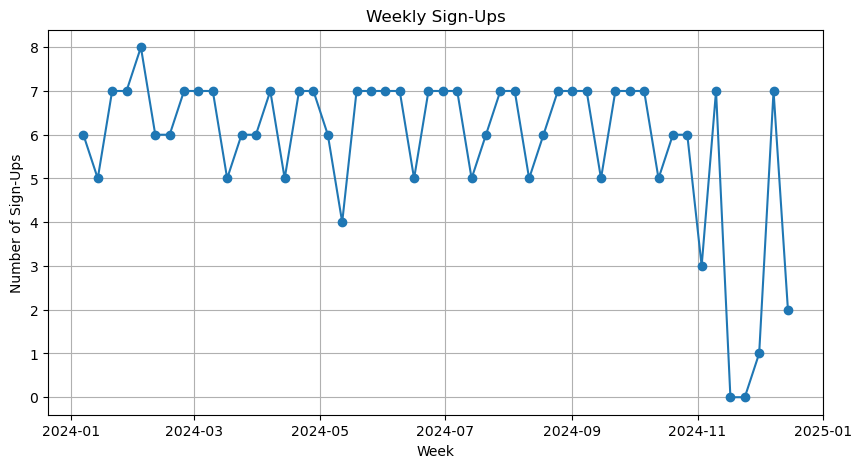

In [158]:
# chart of Sign-ups per week
plt.figure(figsize=(10,5))
plt.plot(
    weekly_signups['signup_date'],
    weekly_signups['signups'],
    marker='o'
)

plt.title('Weekly Sign-Ups')
plt.xlabel('Week')
plt.ylabel('Number of Sign-Ups')
plt.grid(True)

plt.show()

*Analysis*: The number of customer sign-ups varies across the year. 
Weekly trends can help identify periods of increased customer acquisition 
and evaluate the effectiveness of marketing campaigns.

**Sign-ups by source, region, and plan_selected**

In [159]:
# Sign-ups by Source
source_summary = (
    customer_df['source']
    .value_counts()
    .reset_index()
)

source_summary.columns = ['Source', 'Signups']

source_summary.head(10)

,Source,Signups
0,YouTube,58
1,Google,50
2,Referral,49
3,Instagram,48
4,Facebook,40
5,LinkedIn,39
6,Unknown,15


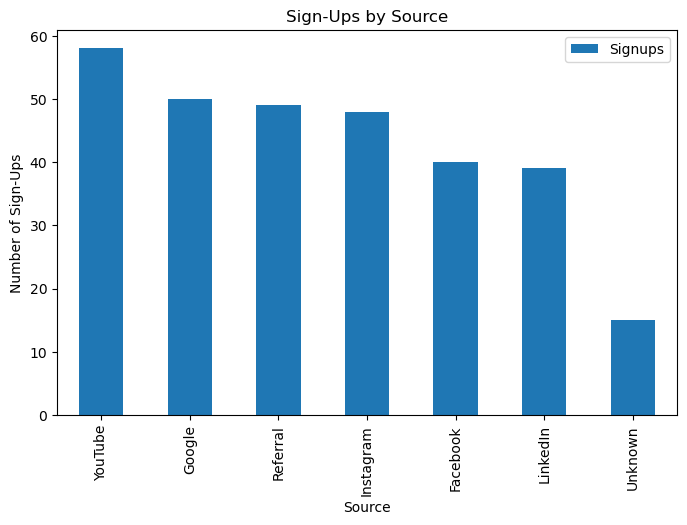

In [160]:
# chart of Sign-ups by Source
source_summary.plot(
    x='Source',
    y='Signups',
    kind='bar',
    figsize=(8,5)
)

plt.title('Sign-Ups by Source')
plt.ylabel('Number of Sign-Ups')

plt.show()

*Analysis*: This analysis shows which acquisition channels generate the highest number of customers and can help prioritize marketing investments.

In [161]:
# Sign-ups by Region
region_summary = (
    customer_df['region']
    .value_counts()
    .reset_index()
)

region_summary.columns = ['Region', 'Signups']
region_summary

,Region,Signups
0,North,65
1,East,61
2,South,59
3,West,45
4,Central,39
5,Unknown,30


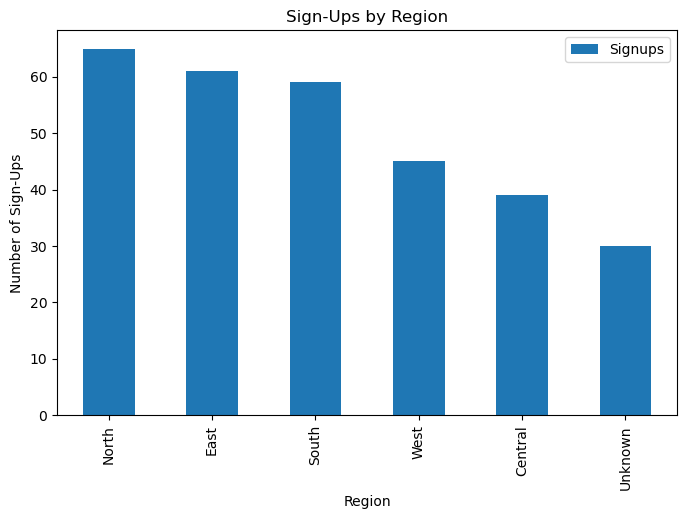

In [162]:
# Chart of Sign-ups by Region
region_summary.plot(
    x='Region',
    y='Signups',
    kind='bar',
    figsize=(8,5)
)

plt.title('Sign-Ups by Region')
plt.ylabel('Number of Sign-Ups')

plt.show()

*Analysis*: Regional sign-up patterns provide insight into market penetration and highlight areas where customer acquisition may need improvement.

In [163]:
# Sign-ups by Plan Selected
plan_summary = (
    customer_df['plan_selected']
    .value_counts()
    .reset_index()
)

plan_summary.columns = ['Plan', 'Customers']

plan_summary

,Plan,Customers
0,Premium,99
1,Pro,94
2,Basic,92
3,Unknown,14


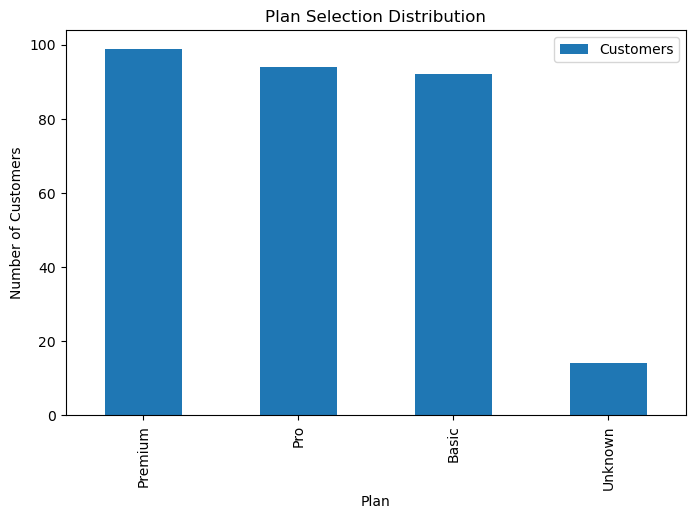

In [164]:
# Chart of Plan selected
plan_summary.plot(
    x='Plan',
    y='Customers',
    kind='bar',
    figsize=(8,5)
)

plt.title('Plan Selection Distribution')
plt.ylabel('Number of Customers')

plt.show()

*Analysis*: The plan distribution indicates customer preferences and can help evaluate pricing and product positioning strategies.

**Marketing opt-in counts by gender**

In [165]:
marketing_gender = (
    customer_df
    .groupby(['gender', 'marketing_opt_in'])
    .size()
    .unstack(fill_value=0)
)

marketing_gender

marketing_opt_in,No,Unknown,Yes
gender,,,
Female,48,0,44
Male,53,1,38
Non-Binary,23,0,19
Other,35,0,24
Unknown,7,0,7


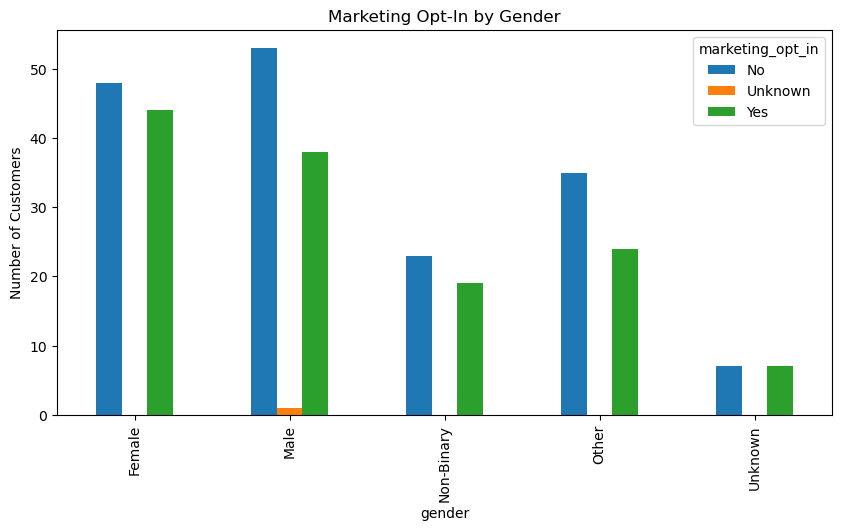

In [166]:
# Chart of Marketing Opt-In by Gender
marketing_gender.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Marketing Opt-In by Gender')
plt.ylabel('Number of Customers')

plt.show()

*Analysis*: Marketing opt-in behaviour differs across demographic groups and can provide insight into customer engagement preferences.

**Age summary: min, max, mean, median, null count**

In [168]:
age_summary = pd.DataFrame({
    'Minimum Age': [customer_df['age'].min()],
    'Maximum Age': [customer_df['age'].max()],
    'Mean Age': [round(customer_df['age'].mean(),2)],
    'Median Age': [customer_df['age'].median()],
    'Null Count': [customer_df['age'].isnull().sum()]
})

age_summary

,Minimum Age,Maximum Age,Mean Age,Median Age,Null Count
0,21.0,60.0,35.46,34.0,0


**Export Results**

In [169]:
weekly_signups.to_csv('weekly_signups.csv', index=False)
source_summary.to_csv('source_summary.csv', index=False)
region_summary.to_csv('region_summary.csv', index=False)
plan_summary.to_csv('plan_summary.csv', index=False)

print("Summary tables exported.")

Summary tables exported.


**4. Answer These Business Questions**

**a. Which acquisition source brought in the most users last month?**

In [183]:
source_summary.sort_values('Signups', ascending=False).iloc[0]

Source     YouTube
Signups         58
Name: 0, dtype: object

*Response*: The acquisition source that brought in the highest number of users was "Youtube".
This channel generated the largest share of customer sign-ups, indicating that it is currently the most effective acquisition channel and may deserve continued marketing investment.

**b. Which region shows signs of missing or incomplete data?**

In [189]:
customer_df[customer_df['region'] == 'Unknown'].shape[0]

30

*Analysis*: The region category "Unknown" shows evidence of incomplete data.
A significant number of customer records do not contain region information, which may limit the accuracy of geographic analysis and regional marketing decisions.
Improving data collection during customer registration would reduce this issue.

**c. Are older users more or less likely to opt in to marketing?**

In [192]:
# first create a new column
customer_df['age_group'] = pd.cut(
    customer_df['age'],
    bins=[18,30,45,60,100],
    labels=['18-30','31-45','46-60','60+']
)
customer_df['age_group'].value_counts(dropna=False)

age_group
18-30    122
31-45    114
46-60     63
60+        0
Name: count, dtype: int64

In [193]:
# Then , we calculate number of users in each group to opt in to Marketing
marketing_by_age = pd.crosstab(
    customer_df['age_group'],
    customer_df['marketing_opt_in']
)

marketing_by_age

marketing_opt_in,No,Unknown,Yes
age_group,,,
18-30,70,1,51
31-45,62,0,52
46-60,34,0,29


*Analysis*: Older users appear less likely to opt in to marketing communications than younger users.
The opt-in number decreases across older age groups, suggesting that mature customers may be less receptive to marketing campaigns. Younger customers show higher engagement with marketing subscriptions, which may indicate stronger interest in promotional content and updates.

**d. Which plan is most commonly selected, and by which age group?**

In [196]:
# most commonly selected plan
customer_df['plan_selected'].value_counts()

plan_selected
Premium    99
Pro        94
Basic      92
Unknown    14
Name: count, dtype: int64

In [198]:
# Age groups by plan
plan_age = pd.crosstab(
    customer_df['age_group'],
    customer_df['plan_selected']
)

plan_age

plan_selected,Basic,Premium,Pro,Unknown
age_group,,,,
18-30,40,37,40,5
31-45,33,43,33,5
46-60,19,19,21,4


*Analysis*: The most frequently selected plan is 'Premium'.
This plan is particularly popular among customers aged between 18-30, indicating that this demographic may find the pricing and features most attractive.

**5. Optional Stretch Task**

**e. Which plan’s users are most likely to contact support?**

In [201]:
#First load the support Support ticket dataset
supptick_df = pd.read_csv("support_tickets.csv")
supptick_df.head(10)

,ticket_id,customer_id,ticket_date,issue_type,resolved
0,TKT0000-1,CUST00203,2024-08-17,Billing,Yes
1,TKT0000-2,CUST00203,2024-07-22,Technical Error,Yes
2,TKT0000-3,CUST00203,2024-07-22,Other,Yes
3,TKT0001-1,CUST00266,2024-09-26,Account Setup,Yes
4,TKT0001-2,CUST00266,2024-10-09,Technical Error,No
5,TKT0001-3,CUST00266,2024-10-21,Other,No
6,TKT0002-1,CUST00152,2024-01-10,Other,Yes
7,TKT0003-1,CUST00009,2024-10-03,Technical Error,No
8,TKT0004-1,CUST00233,2024-09-18,Other,Yes
9,TKT0004-2,CUST00233,2024-08-21,Account Setup,Yes


In [26]:
# Support Ticket Table's info: number of rows, number of columns, data types, missing values
supptick_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ticket_id    123 non-null    object
 1   customer_id  123 non-null    object
 2   ticket_date  123 non-null    object
 3   issue_type   123 non-null    object
 4   resolved     123 non-null    object
dtypes: object(5)
memory usage: 4.9+ KB


In [206]:
# Join both datasets:
merged_df = customer_df.merge(supptick_df, on='customer_id', how='left')
merged_df.head(10)

,customer_id,name,email,signup_date,source,region,plan_selected,marketing_opt_in,age,gender,age_group,ticket_id,ticket_date,issue_type,resolved
0,CUST00000,Joshua Bryant,NaN,NaT,Instagram,Unknown,Basic,No,34.0,Female,31-45,NaN,NaN,NaN,NaN
1,CUST00001,Nicole Stewart,nicole1@example.com,2024-02-01,LinkedIn,West,Basic,Yes,29.0,Male,18-30,NaN,NaN,NaN,NaN
2,CUST00002,Rachel Allen,rachel2@example.com,2024-03-01,Google,North,Premium,Yes,34.0,Non-Binary,31-45,NaN,NaN,NaN,NaN
3,CUST00003,Zachary Sanchez,zachary3@mailhub.org,2024-04-01,YouTube,Unknown,Pro,No,40.0,Male,31-45,NaN,NaN,NaN,NaN
4,CUST00004,NaN,matthew4@mailhub.org,2024-05-01,LinkedIn,West,Premium,No,25.0,Other,18-30,NaN,NaN,NaN,NaN
5,CUST00005,John Gonzales,john5@mailhub.org,2024-06-01,Facebook,South,Premium,No,34.0,Other,31-45,TKT0008-1,2024-06-04,Other,Yes
6,CUST00006,Crystal Mason,crystal6@mailhub.org,2024-07-01,YouTube,North,Unknown,Yes,40.0,Male,31-45,NaN,NaN,NaN,NaN
7,CUST00007,Michael Bailey,michael7@mailhub.org,2024-08-01,YouTube,Central,Pro,Yes,60.0,Other,46-60,TKT0036-1,2024-08-07,Billing,Yes
8,CUST00007,Michael Bailey,michael7@mailhub.org,2024-08-01,YouTube,Central,Pro,Yes,60.0,Other,46-60,TKT0036-2,2024-08-23,Other,Yes
9,CUST00008,Bianca Morris,bianca8@example.com,2024-09-01,Referral,West,Pro,Yes,25.0,Male,18-30,NaN,NaN,NaN,NaN


In [209]:
# Identify customers who contacted support
support_by_plan = (
    merged_df
    .dropna(subset=['ticket_id'])  # only customers with tickets
    .groupby('plan_selected')['ticket_id']
    .count()
    .sort_values(ascending=False)
)

support_by_plan

plan_selected
Pro        47
Basic      42
Premium    26
Unknown     8
Name: ticket_id, dtype: int64

In [210]:
# Calculate support rate by plan
total_customers = (
    customer_df['plan_selected']
    .value_counts()
)

customers_with_tickets = (
    merged_df
    .dropna(subset=['ticket_id'])
    .groupby('plan_selected')['customer_id']
    .nunique()
)

support_rate = pd.DataFrame({
    'Total Customers': total_customers,
    'Customers Contacting Support': customers_with_tickets
})

support_rate['Support Rate (%)'] = (
    support_rate['Customers Contacting Support']
    / support_rate['Total Customers']
    * 100
)

support_rate.round(2)

,Total Customers,Customers Contacting Support,Support Rate (%)
plan_selected,,,
Basic,92,20,21.74
Premium,99,12,12.12
Pro,94,24,25.53
Unknown,14,4,28.57


*Analysis*: Users of the Pro plan are the most likely to contact support among the standard subscription plans, with a support contact rate of 25.53%.

Although the "Unknown" category shows the highest rate (28.57%), it represents incomplete plan information and should be interpreted with caution.

Premium users have the lowest support contact rate at 12.12%, suggesting that Premium customers may experience fewer issues or benefit from a smoother onboarding experience.

The higher support activity among Pro users may indicate a need for additional guidance, documentation, or customer support resources for this customer segment.

**Recommandations**
1. Increase investment in YouTube marketing campaigns, as YouTube generated the highest number of customer sign-ups.

2. Improve data collection processes by making key fields such as region, plan selection, and customer demographics mandatory during registration.

3. Review the onboarding experience for Pro plan customers, as they have the highest support contact rate among standard subscription plans.

4. Consider targeted marketing campaigns for customers aged 31–45, as this group shows strong adoption of the Premium plan and relatively high marketing engagement.

**Save Dataset and the solved task**

In [219]:
customer_df.to_csv('customer_signups_cleaned.csv',index=False)
print("Clean dataset saved.")

Clean dataset saved.
